Для інсталювання необхідного пакету потрібно ввести в терміналі:

```python
pip install pulp
```

Нехай є математична модель:

\begin{align}
min(max) \hspace{1cm} z & = x_1 + x_2, \\
s.t. \hspace{0.5cm} -2x_1+3x_2 & \leq 9; \\
\hspace{0.5cm} x_1 - 2x_2 & \leq 2; \\
\hspace{0.5cm} x_1 + x_2 & \leq 8; \\
x_1 & \geq 0; \\
x_2 & \geq 0. \\
\end{align}

## Блок 0. Підключення необхідних пакетів

In [43]:
import warnings
warnings.filterwarnings('ignore')

from pulp import *
import matplotlib.pyplot as plt
import numpy as np

# Додаткові команди для відображення графіків
%config InlineBackend.figure_format = 'svg'
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 5, 5

## Блок 1. Реалізація математичної моделі лінійного програмування

In [44]:
# Створення об'єкту математичної моделі
prob = LpProblem("Simple LP Problem", LpMinimize)

In [45]:
# Оголошення змінних мат. моделі
x1 = LpVariable("x1", 0)
x2 = LpVariable("x2", 0)

In [46]:
# Оголошення та ініціалізація цільової функції
prob += -(x1 + x2)

In [47]:
# Оголошення та ініціалізація обмежень моделі
prob += -2*x1 + 3*x2 <= 9, "1st const"
prob += x1 - 2*x2 <= 2, "2nd const"
prob += x1 + x2 <= 8, "3rd const"

In [48]:
# Розв'язок ЗЛП
prob.solve(PULP_CBC_CMD(msg=1))

1

## Блок 2. Виведення результату математичної моделі

In [49]:
# Виведення результату оптимізації
print ("Статуc ЗЛП: ", LpStatus[prob.status])

Статуc ЗЛП:  Optimal


In [50]:
print("Результат:")
for v in prob.variables():
    print (v.name, "=", v.varValue)

Результат:
x1 = 3.0
x2 = 5.0


In [51]:
print ("Оптимальне значення цільової функції: z =",
       -value(prob.objective))

Оптимальне значення цільової функції: z = 8.0


## Блок 3. Реалізація графічного методу

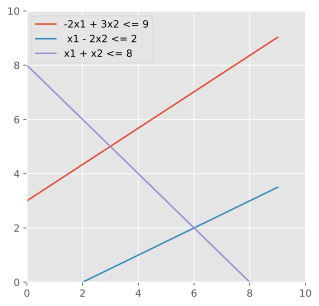

In [52]:
# Побудова багатокутника розв'язків
x = np.arange(0, 10)
plt.plot(x, 3 + 0.67*x, label = '-2x1 + 3x2 <= 9')
plt.plot(x, -1 + 0.5*x, label= ' x1 - 2x2 <= 2')
plt.plot(x, 8 - x, label = 'x1 + x2 <= 8')

plt.axis([0, 10, 0, 10])
plt.grid(True)
plt.legend()
plt.show()

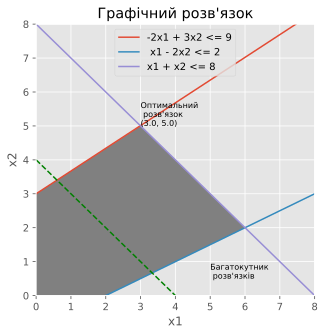

In [53]:
# Переформатування змінних
x_1 = x1.value()
x_2 = x2.value()

# Побудова багатокутника розв'язків
x = np.arange(0, 10) # задання меж змінних x1 та x2
plt.plot(x, 3 + 0.67*x, label = '-2x1 + 3x2 <= 9')
plt.plot(x, -1 + 0.5*x, label= ' x1 - 2x2 <= 2')
plt.plot(x, 8 - x, label = 'x1 + x2 <= 8')

# Зображення перпендикуляра до вектор-градієнта
plt.plot(x, 4 - x, 'g--')

# Ініціалізація границь багатокутника розв'язків та
# зафрбування його сірим кольором
x = [0, 0, 3, 6, 2]
y = [0, 3, 5, 2, 0]
plt.fill(x, y, 'grey')

# Виведення додаткових анотацій на графіку
plt.text(5, 0.5, 'Багатокутник \n розв\'язків', size='8')
plt.annotate('Оптимальний \n розв\'язок\n({}, {})'.format(x_1, x_2),
             size='8',
             xy=(x_1, x_2))

# Задання основних параметрів графіку
plt.xlabel('x1')  # вісь х1
plt.ylabel('x2')  # вісь х2
plt.title('Графічний розв\'язок') # назва графіку
plt.axis([0, 8, 0, 8])  # межі графіку
plt.grid(True)  # зображення сітки графіку
plt.legend()  # зображення легенди графіку
plt.show()  # виведення графіку